# Imports & Setup

In [1]:
# Imports for Hugging Face tokenizer library
from tokenizers import Tokenizer, normalizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# Data loading
import json

# Data types
from typing import List

# File handling
import os
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Get project root
ROOT_DIR = Path(os.getcwd()).resolve().parent
print("Project root:", ROOT_DIR)

Project root: /workspace


# Train Tokenizer

In [3]:
# Loads all text from jsonl dataset to generator object
def data_iterator(filepath: str):
  with(open(filepath) as f): # Open file
    for line in f:
      obj = json.loads(line) # Load line in file
      for text in obj["text"]: # Loop through all sections under text key in file
        yield obj["text"][text] # Yield the raw text from the section

In [4]:
def train_tokenizer(corpus_filepath: str, vocab_size: int, min_frequency: int, special_tokens: List[str]):
    tokenizer = Tokenizer(BPE()) # Init tokenizer

    tokenizer.normalizer = normalizers.NFKC() # Unicode normalization
    tokenizer.pre_tokenizer = ByteLevel() # Set tokenizer to split at byte level (BPE)

    # Trainer config
    trainer = BpeTrainer(
        vocab_size=vocab_size, # Size of vocab
        min_frequency=min_frequency, # Min frequency of token in text for it to be added to vocab
        special_tokens=special_tokens # Manually add special tokens that are not in training text
    )

    # Train the tokenizer and create vocabulary
    tokenizer.train_from_iterator(
        iterator=data_iterator(corpus_filepath),
        trainer=trainer
        )

    tokenizer.decoder = ByteLevelDecoder() # Set decoder

    return tokenizer

def save_tokenizer(tokenizer: Tokenizer, save_filepath: str):
    os.makedirs(save_filepath, exist_ok=True) # Make the folder if it doesn't exist
    tokenizer.save(f"{save_filepath}/tokenizer.json") # Save tokenizer.json
    tokenizer.model.save(f"{save_filepath}/") # Save vocab.json and merges.txt

In [5]:
# Run the tokenizer training on several vocab sizes
vocab_sizes = [ 8_000, 16_000, 24_000, 32_000, 40_000, 48_000, 56_000]

tokenizers = [] # List for tokenizers

# Create each tokenizer for each vocab size
for vocab_size in vocab_sizes:
    this_tokenizer = {}
    this_tokenizer["vocab_size"] = vocab_size
    this_tokenizer["tokenizer"] = train_tokenizer(
        corpus_filepath=f"{ROOT_DIR}/data_raw/pretraining_data/data.jsonl",
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=[
            "<|endoftext|>"
        ]
        )
    tokenizers.append(this_tokenizer)
    print(f"Trained tokenizer with vocab size {vocab_size}")




Trained tokenizer with vocab size 8000



Trained tokenizer with vocab size 16000



Trained tokenizer with vocab size 24000



Trained tokenizer with vocab size 32000



Trained tokenizer with vocab size 40000



Trained tokenizer with vocab size 48000



Trained tokenizer with vocab size 56000


# diagnostics

## Finding best tokenizer vocab size

In [6]:
# Check diagnostics for each tokenizer to make vocab size decision
for i, element in enumerate(tokenizers):
    tokenizer = element["tokenizer"]
    with(open(f"{ROOT_DIR}/data_raw/pretraining_data/data.jsonl") as f): # Open file
        tokens_in_articles = []
        chars_in_articles = []
        words_in_articles = []
        for line in f:
            tokens_this_article = 0
            chars_this_article = 0
            words_this_article = 0
            obj = json.loads(line) # Load line in file (single article)
            for text in obj["text"]: # Loop through all sections in the article
                section_text = obj["text"][text] # Get section
                tokens_this_article += len(tokenizer.encode(section_text)) # Add tokens in section of article
                chars_this_article += len(section_text) # Add chars in section of article
                words_this_article += len(section_text.split()) # Add words in section of article
            tokens_in_articles.append(tokens_this_article) # Add tokens per article to list
            chars_in_articles.append(chars_this_article) # Add chars per article to list
            words_in_articles.append(words_this_article) # Add words per article to list
        
    average_tokens_per_article = sum(tokens_in_articles) / len(tokens_in_articles) # Calc avg
    tokenizers[i]["average_tokens_per_article"] = average_tokens_per_article

    tokens_per_1000_chars = sum(tokens_in_articles) / sum(chars_in_articles) * 1000 # Calc tokens per 1000 chars
    tokenizers[i]["tokens_per_1000_chars"] = tokens_per_1000_chars
    
    tokens_per_word = sum(tokens_in_articles) / sum(words_in_articles) # Calc tokens per word
    tokenizers[i]["tokens_per_word"] = tokens_per_word
    
    print("Complete analysis for tokenizer with vocab size ", element["vocab_size"])

Complete analysis for tokenizer with vocab size  8000
Complete analysis for tokenizer with vocab size  16000
Complete analysis for tokenizer with vocab size  24000
Complete analysis for tokenizer with vocab size  32000
Complete analysis for tokenizer with vocab size  40000
Complete analysis for tokenizer with vocab size  48000
Complete analysis for tokenizer with vocab size  56000


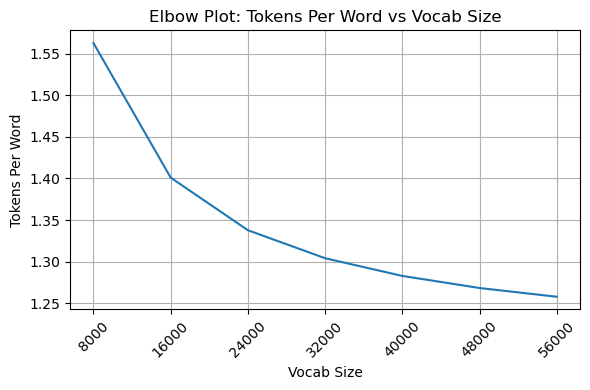

In [7]:
# Elbow plot for tokens per word vs vocab size
plt.figure(figsize=(6, 4))  # width, height in inches
sns.lineplot(
    y=[t["tokens_per_word"] for t in tokenizers],
    x=[t["vocab_size"] for t in tokenizers]
)
plt.title("Elbow Plot: Tokens Per Word vs Vocab Size")
plt.ylabel("Tokens Per Word")
plt.xlabel("Vocab Size")
plt.xticks(ticks=[t["vocab_size"] for t in tokenizers], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{ROOT_DIR}/results/elbow_plot_tokens_per_word_vs_vocab_size.png")
plt.show()

## Evaluate selected tokenizer

In [8]:
# Check tokenizers dict
tokenizers[2]

{'vocab_size': 24000,
 'tokenizer': Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"<|endoftext|>", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}], normalizer=NFKC(), pre_tokenizer=ByteLevel(add_prefix_space=True, trim_offsets=True, use_regex=True), post_processor=None, decoder=ByteLevel(add_prefix_space=True, trim_offsets=True, use_regex=True), model=BPE(dropout=None, unk_token=None, continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={"<|endoftext|>":0, "!":1, """:2, "#":3, "$":4, "%":5, "&":6, "'":7, "(":8, ")":9, "*":10, "+":11, ",":12, "-":13, ".":14, "/":15, "0":16, "1":17, "2":18, "3":19, "4":20, "5":21, "6":22, "7":23, "8":24, "9":25, ":":26, ";":27, "<":28, "=":29, ">":30, "?":31, "@":32, "A":33, "B":34, "C":35, "D":36, "E":37, "F":38, "G":39, "H":40, "I":41, "J":42, "K":43, "L":44, "M":45, "N":46, "O":47, "P":48, "Q":49, "R"

In [9]:
tokenizer_dict = tokenizers[2]

In [10]:
# Set selected tokenizer for testing
testing_tokenizer = tokenizer_dict["tokenizer"]

In [11]:
# Verify vocab size
print("Vocab size:", testing_tokenizer.get_vocab_size())

Vocab size: 24000


In [12]:
# Example encodings
def print_encoding_example(text: str):
    embeded = testing_tokenizer.encode(text) # Encode to to tokens
    decoded = testing_tokenizer.decode(embeded.ids) # Decode tokens back to text
    # Print report
    print("Original text:", text)
    print("Tokens:", embeded.tokens)
    print("Token IDs:", embeded.ids)
    print("Decoded:", decoded)
    print() # Spacing

# Non domain specific text
print_encoding_example("Testing this string to make some tokens.")

# Domain specific text
print_encoding_example("Acetaminophen is an over the counter medication used to treat pain and fever.")

# Mix domain specific and non domain specific text
print_encoding_example("What can I do for a headache?")

# Testing on medical terms
print_encoding_example("Hypertension, hyperglycemia, neuropathy, and bronchitis are medical terms.")

Original text: Testing this string to make some tokens.
Tokens: ['ĠTesting', 'Ġthis', 'Ġstring', 'Ġto', 'Ġmake', 'Ġsome', 'Ġto', 'k', 'ens', '.']
Token IDs: [22197, 502, 17557, 243, 2313, 651, 243, 75, 800, 14]
Decoded:  Testing this string to make some tokens.

Original text: Acetaminophen is an over the counter medication used to treat pain and fever.
Tokens: ['ĠAcet', 'aminophen', 'Ġis', 'Ġan', 'Ġover', 'Ġthe', 'Ġcounter', 'Ġmedication', 'Ġused', 'Ġto', 'Ġtreat', 'Ġpain', 'Ġand', 'Ġfever', '.']
Token IDs: [7283, 3865, 256, 226, 599, 216, 3979, 1408, 417, 243, 399, 937, 238, 2496, 14]
Decoded:  Acetaminophen is an over the counter medication used to treat pain and fever.

Original text: What can I do for a headache?
Tokens: ['ĠWhat', 'Ġcan', 'ĠI', 'Ġdo', 'Ġfor', 'Ġa', 'Ġheadache', '?']
Token IDs: [15910, 369, 283, 741, 268, 207, 2524, 31]
Decoded:  What can I do for a headache?

Original text: Hypertension, hyperglycemia, neuropathy, and bronchitis are medical terms.
Tokens: ['ĠHyper

In [ ]:
# Save selected tokenizer
save_tokenizer(
    tokenizer=testing_tokenizer,
    save_filepath=f"{ROOT_DIR}/code/model/tokenizer"
)

In [14]:
# Save tokenizer report
report = f'''# Tokenizer Report

Vocabulary size: {tokenizer_dict["vocab_size"]}
Average tokens per article: {tokenizer_dict["average_tokens_per_article"]:.2f}
Tokens per 1000 words: {tokenizer_dict["tokens_per_1000_chars"]:.2f}
Tokens per word: {tokenizer_dict["tokens_per_word"]:.2f}
'''

with open(f"{ROOT_DIR}/results/tokenizer_report.md", 'w', encoding='utf-8') as f:
    f.writelines(report)
    f.close()